# Analisis ISPU (Indeks Standar Pencemaran Udara) DKI Jakarta Tahun 2022

## Tentang ISPU

ISPU (Indeks Standar Pencemaran Udara) adalah angka tanpa satuan yang menggambarkan kondisi kualitas udara ambien pada waktu dan lokasi tertentu, berdasarkan dampaknya terhadap kesehatan manusia, nilai estetika, dan makhluk hidup lainnya.

| Parameter | Keterangan |
|---|---|
| **PM10** | Partikel berdiameter ≤ 10 mikrometer |
| **PM2.5** | Partikel berdiameter ≤ 2.5 mikrometer — paling berbahaya bagi paru-paru |
| **SO2** | Sulfur Dioksida — dari pembakaran bahan bakar fosil |
| **CO** | Karbon Monoksida — dari emisi kendaraan bermotor |
| **O3** | Ozon — polutan sekunder dari reaksi NOx dan VOC di bawah sinar matahari |
| **NO2** | Nitrogen Dioksida — dari emisi kendaraan dan industri |

**Kategori ISPU:**
- **BAIK** (0–50): Tidak memberikan efek negatif
- **SEDANG** (51–100): Tidak berpengaruh bagi kesehatan manusia dan hewan
- **TIDAK SEHAT** (101–199): Bersifat merugikan pada manusia, hewan, dan tumbuhan

---
## Tahap 1: Business Understanding

### 1.1 Latar Belakang

DKI Jakarta sebagai ibu kota Indonesia menghadapi masalah polusi udara yang signifikan akibat padatnya kendaraan bermotor, industri, dan aktivitas perkotaan. Data ISPU tahun 2022 menyediakan informasi harian tentang kualitas udara dari **5 stasiun pemantauan (DKI1–DKI5)** di berbagai wilayah Jakarta.

**Mengapa analisis ini penting?**
- Kualitas udara buruk berdampak langsung pada kesehatan masyarakat (ISPA, asma, penyakit kardiovaskular)
- Pemerintah memerlukan sistem prediksi otomatis untuk *early warning system*
- Pemahaman polutan dominan membantu kebijakan pengendalian pencemaran yang tepat sasaran

### 1.2 Tujuan Bisnis

1. **Klasifikasi Otomatis** — Membangun model ML yang mengklasifikasikan kategori kualitas udara (BAIK/SEDANG/TIDAK SEHAT) berdasarkan nilai 6 polutan
2. **Identifikasi Polutan Kritis** — Mengetahui polutan mana yang paling berpengaruh pada kategori ISPU
3. **Analisis Pola Temporal** — Mengidentifikasi tren musiman dan bulanan kualitas udara DKI Jakarta
4. **Deployment Dashboard** — Membangun dashboard interaktif untuk monitoring dan prediksi real-time

### 1.3 Pertanyaan Analitik

1. Apa distribusi kategori kualitas udara DKI Jakarta sepanjang tahun 2022?
2. Polutan mana yang paling berkontribusi pada kategori TIDAK SEHAT?
3. Apakah ada pola musiman (kemarau vs hujan) pada kualitas udara?
4. Model ML mana yang paling akurat dalam memprediksi kategori udara?
5. Lokasi SPKU mana yang paling sering mencatat kualitas udara buruk?

### 1.4 Kriteria Keberhasilan

| Kriteria | Target |
|---|---|
| Akurasi model | ≥ 80% |
| F1-Score (macro) | ≥ 0.75 |
| Dashboard | Berhasil dijalankan dan dapat prediksi real-time |
| Feature Importance | Mengidentifikasi polutan paling berpengaruh |

---
## Library yang Digunakan

Berikut adalah daftar library Python yang digunakan beserta penjelasan fungsinya:

| Library | Versi | Fungsi |
|---|---|---|
| **pandas** | latest | Manipulasi dan analisis data tabular (DataFrame, Series) |
| **numpy** | latest | Operasi numerik, array multidimensi, fungsi matematika |
| **matplotlib** | latest | Library visualisasi data utama — membuat grafik statis |
| **seaborn** | latest | Visualisasi statistik berbasis matplotlib — heatmap, boxplot |
| **scikit-learn** | latest | Framework ML lengkap: preprocessing, model, evaluasi |
| **imbalanced-learn** | latest | Menangani ketidakseimbangan kelas — SMOTE |
| **joblib** | latest | Serialisasi model ML (simpan & muat file .pkl) |



In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

# --- Data Manipulation & Analysis ---
import pandas as pd          # Manipulasi data tabular
import numpy as np           # Operasi numerik dan array

# --- Visualization ---
import matplotlib.pyplot as plt      # Visualisasi grafik statis
import matplotlib.patches as mpatches
import seaborn as sns                # Visualisasi statistik (heatmap, boxplot)

# --- Machine Learning: Preprocessing ---
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- Machine Learning: Models ---
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# --- Machine Learning: Evaluation ---
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# --- Data Augmentation ---
from imblearn.over_sampling import SMOTE   # Synthetic Minority Over-sampling

# --- Model Persistence ---
import joblib   # Simpan & muat model ML
import os
import json
import warnings
warnings.filterwarnings('ignore')

# --- Display Settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## Tahap 2: Data Understanding

Pada tahap ini kita akan:
1. Memuat dataset dan memeriksa strukturnya
2. Menganalisis statistik deskriptif
3. Mengidentifikasi missing values dan anomali data
4. Memvisualisasikan distribusi dan pola data

In [2]:
# --- Load Dataset ---
DATA_PATH = 'dataset/Filedata Indeks Standar Pencemaran Udara ISPU Tahun 2022.csv'

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()  # Simpan raw data; df akan digunakan untuk EDA

print('Dataset berhasil dimuat!')
print(f'   Jumlah baris  : {df.shape[0]}')
print(f'   Jumlah kolom  : {df.shape[1]}')
print(f'   Ukuran memori : {df.memory_usage(deep=True).sum() / 1024:.2f} KB')
print()
print('=== 5 Data Pertama ===')
df.head()

Dataset berhasil dimuat!
   Jumlah baris  : 365
   Jumlah kolom  : 12
   Ukuran memori : 43.87 KB

=== 5 Data Pertama ===


,critical,categori,lokasi_spku,periode_data,tanggal,pm_10,pm_duakomalima,so2,co,o3,no2,max
0,"PM2,5",SEDANG,DKI4,202201,2022-01-01,57,85,48,13,34,18,85
1,"PM2,5",TIDAK SEHAT,DKI4,202201,2022-01-31,72,119,58,44,53,44,119
2,"PM2,5",TIDAK SEHAT,DKI4,202201,2022-01-30,75,129,53,25,59,50,129
3,"PM2,5",TIDAK SEHAT,DKI4,202201,2022-01-29,65,120,52,30,52,46,120
4,"PM2,5",SEDANG,DKI3,202201,2022-01-28,63,84,52,12,60,28,84


In [3]:
# --- Informasi & Struktur Dataset ---
print('=== INFORMASI DATASET ===')
print()
print(f'Shape: {df.shape}')
print()
print('Kolom dan Tipe Data:')
print('-' * 50)
for col in df.columns:
    dtype = str(df[col].dtype)
    nunique = df[col].nunique()
    print(f'  {col:<25} | {dtype:<10} | {nunique} unique values')
print()
print('=== df.info() ===')
df.info()

=== INFORMASI DATASET ===

Shape: (365, 12)

Kolom dan Tipe Data:
--------------------------------------------------
  critical                  | str        | 3 unique values
  categori                  | str        | 3 unique values
  lokasi_spku               | str        | 6 unique values
  periode_data              | int64      | 12 unique values
  tanggal                   | str        | 365 unique values
  pm_10                     | int64      | 63 unique values
  pm_duakomalima            | int64      | 95 unique values
  so2                       | int64      | 24 unique values
  co                        | int64      | 36 unique values
  o3                        | int64      | 92 unique values
  no2                       | int64      | 43 unique values
  max                       | int64      | 94 unique values

=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ----

In [4]:
# --- Statistik Deskriptif ---
print('=== STATISTIK DESKRIPTIF (Fitur Numerik) ===')
df.describe().round(2)

=== STATISTIK DESKRIPTIF (Fitur Numerik) ===


,periode_data,pm_10,pm_duakomalima,so2,co,o3,no2,max
count,365.00,365.00,365.00,365.00,365.00,365.00,365.00,365.00
mean,202206.53,59.82,92.94,47.93,18.42,57.24,28.75,93.85
std,3.45,13.33,24.42,4.57,7.10,23.35,8.68,24.44
min,202201.00,23.00,40.00,37.00,7.00,15.00,6.00,49.00
25%,202204.00,52.00,75.00,44.00,14.00,39.00,23.00,76.00
50%,202207.00,60.00,92.00,49.00,17.00,54.00,28.00,93.00
75%,202210.00,68.00,111.00,51.00,21.00,71.00,34.00,111.00
max,202212.00,95.00,165.00,62.00,55.00,181.00,52.00,181.00


In [5]:
# --- Analisis Missing Values ---
print('=== ANALISIS MISSING VALUES ===')
print()
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})

print(missing_df)
print()

missing_rows = df.isnull().any(axis=1).sum()
print(f'Total baris dengan minimal 1 missing value: {missing_rows}')
print()

# Tampilkan baris yang memiliki missing values
if missing_rows > 0:
    print('Baris dengan missing values:')
    print(df[df.isnull().any(axis=1)])

# Cek nilai '0' pada lokasi_spku yang bukan merupakan lokasi valid
print()
print('=== ANOMALI: Nilai lokasi_spku ===')
print(df['lokasi_spku'].value_counts())

=== ANALISIS MISSING VALUES ===

                Jumlah Missing  Persentase (%)
critical                     1            0.27
categori                     0            0.00
lokasi_spku                  0            0.00
periode_data                 0            0.00
tanggal                      0            0.00
pm_10                        0            0.00
pm_duakomalima               0            0.00
so2                          0            0.00
co                           0            0.00
o3                           0            0.00
no2                          0            0.00
max                          0            0.00

Total baris dengan minimal 1 missing value: 1

Baris dengan missing values:
    critical categori lokasi_spku  periode_data     tanggal  pm_10  \
121      NaN   SEDANG           0        202205  2022-05-31     63   

     pm_duakomalima  so2  co  o3  no2  max  
121             100   44  44  59   44  100  

=== ANOMALI: Nilai lokasi_spku ===
lokasi_spku


In [6]:
# --- Distribusi Variabel Kategorikal ---
print('=== DISTRIBUSI VARIABEL KATEGORIKAL ===')
print()

for col in ['critical', 'categori', 'lokasi_spku']:
    print(f'--- Kolom: {col} ---')
    vc = df[col].value_counts()
    pct = (df[col].value_counts(normalize=True) * 100).round(2)
    result = pd.DataFrame({'Jumlah': vc, 'Persentase (%)': pct})
    print(result)
    print()

# Cek anomali tanggal Februari
print('=== ANOMALI: Sampel Tanggal Februari (periode_data=202202) ===')
print(df[df['periode_data'] == 202202][['tanggal', 'periode_data', 'lokasi_spku']].head(5))
print('Terdeteksi: tahun Februari tertulis 2020 (seharusnya 2022)')
print()

# Cek Excel serial date
print('=== ANOMALI: Baris dengan tanggal berformat angka ===')
anomali_mask = df['tanggal'].apply(lambda x: str(x).replace('.', '').isnumeric())
print(df[anomali_mask])

=== DISTRIBUSI VARIABEL KATEGORIKAL ===

--- Kolom: critical ---
          Jumlah  Persentase (%)
critical                        
PM2,5        333           91.48
O3            25            6.87
SO2            6            1.65

--- Kolom: categori ---
             Jumlah  Persentase (%)
categori                           
SEDANG          225           61.64
TIDAK SEHAT     137           37.53
BAIK              3            0.82

--- Kolom: lokasi_spku ---
             Jumlah  Persentase (%)
lokasi_spku                        
DKI4            266           72.88
DKI2             39           10.68
DKI3             33            9.04
DKI5             22            6.03
DKI1              4            1.10
0                 1            0.27

=== ANOMALI: Sampel Tanggal Februari (periode_data=202202) ===
       tanggal  periode_data lokasi_spku
31  2020-02-01        202202        DKI3
32  2020-02-28        202202        DKI5
33  2020-02-27        202202        DKI4
34  2020-02-26       

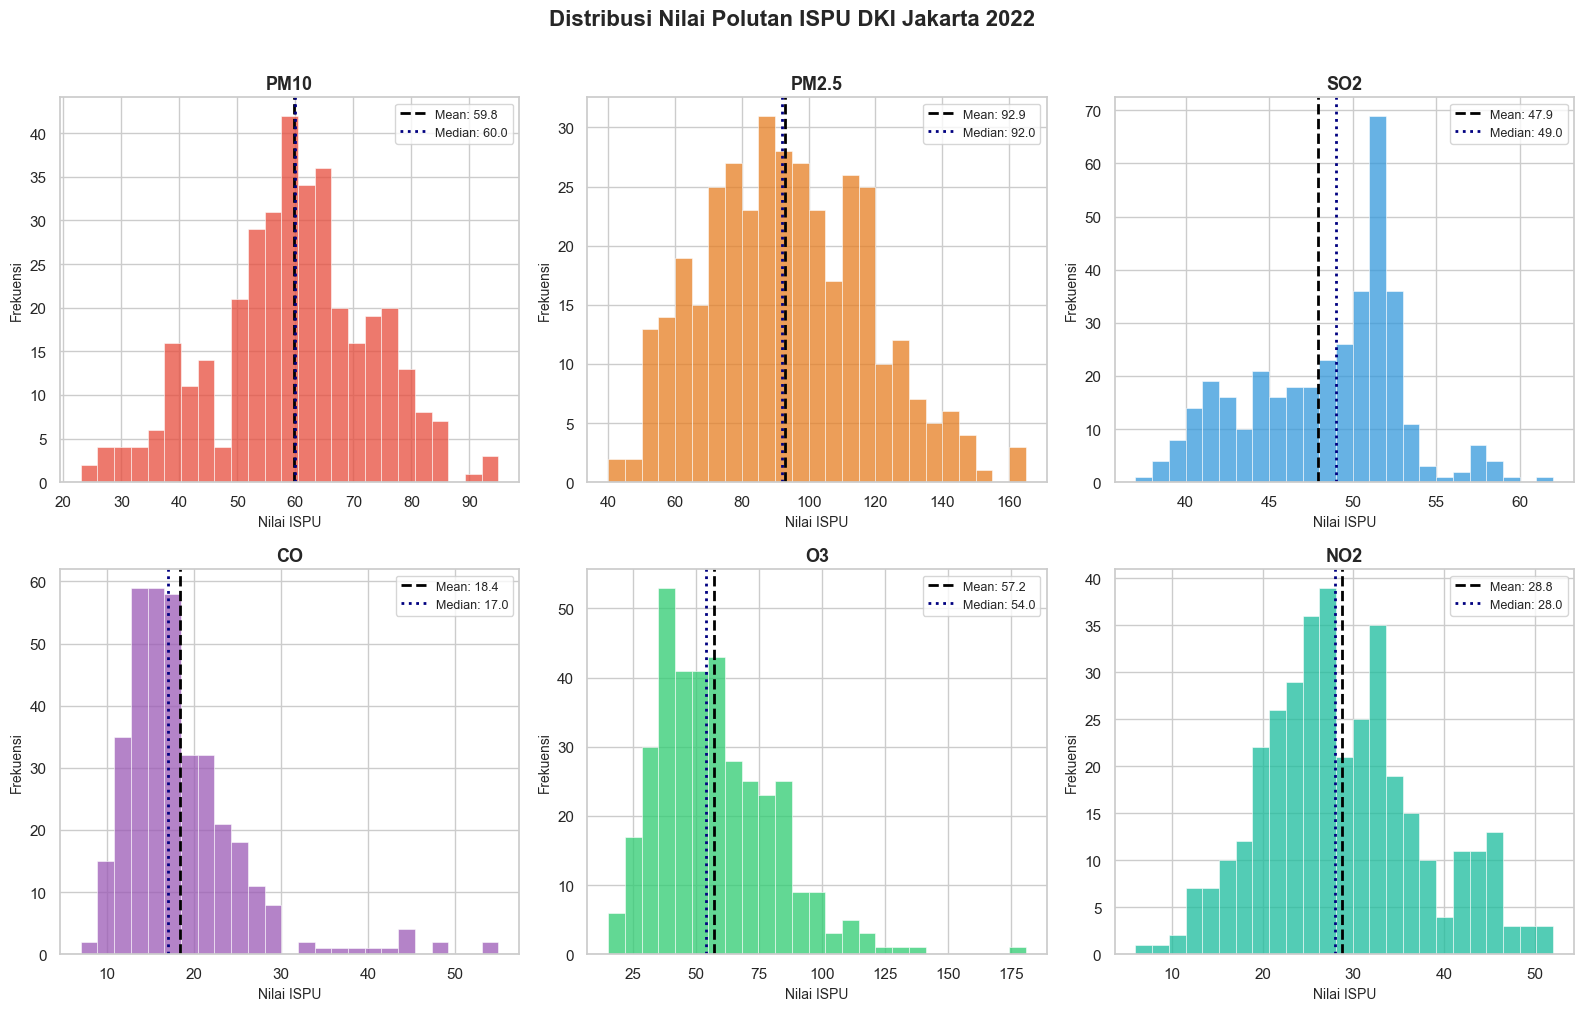

Distribusi polutan divisualisasikan


In [7]:
# --- Visualisasi Distribusi Polutan ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribusi Nilai Polutan ISPU DKI Jakarta 2022', fontsize=16, fontweight='bold', y=1.01)

polutan = ['pm_10', 'pm_duakomalima', 'so2', 'co', 'o3', 'no2']
labels  = ['PM10', 'PM2.5', 'SO2', 'CO', 'O3', 'NO2']
colors  = ['#e74c3c', '#e67e22', '#3498db', '#9b59b6', '#2ecc71', '#1abc9c']

for idx, (pol, label, color) in enumerate(zip(polutan, labels, colors)):
    ax   = axes[idx // 3][idx % 3]
    data = df[pol].dropna()
    ax.hist(data, bins=25, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.axvline(data.mean(),   color='black',  linestyle='--', linewidth=2, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='navy',   linestyle=':',  linewidth=2, label=f'Median: {data.median():.1f}')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Nilai ISPU', fontsize=10)
    ax.set_ylabel('Frekuensi', fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print('Distribusi polutan divisualisasikan')

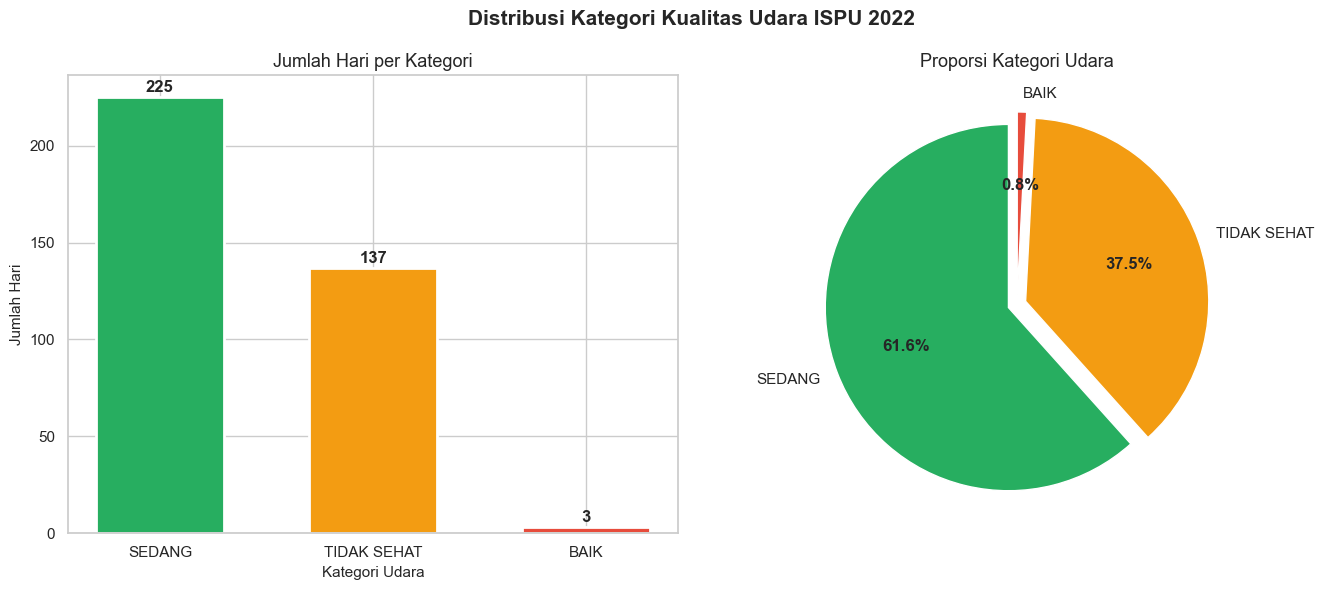

Distribusi Kategori:
  SEDANG         : 225 hari (61.6%)
  TIDAK SEHAT    : 137 hari (37.5%)
  BAIK           : 3 hari (0.8%)


In [8]:
# --- Distribusi Kategori Udara ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribusi Kategori Kualitas Udara ISPU 2022', fontsize=15, fontweight='bold')

cat_counts  = df['categori'].value_counts()
colors_cat  = ['#27ae60', '#f39c12', '#e74c3c']

# Bar Chart
bars = ax1.bar(cat_counts.index, cat_counts.values, color=colors_cat,
               edgecolor='white', linewidth=2, width=0.6)
ax1.set_title('Jumlah Hari per Kategori', fontsize=13)
ax1.set_xlabel('Kategori Udara', fontsize=11)
ax1.set_ylabel('Jumlah Hari', fontsize=11)
for bar, val in zip(bars, cat_counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie Chart
wedges, texts, autotexts = ax2.pie(
    cat_counts.values, labels=cat_counts.index, colors=colors_cat,
    autopct='%1.1f%%', startangle=90, explode=[0.05] * len(cat_counts)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax2.set_title('Proporsi Kategori Udara', fontsize=13)

plt.tight_layout()
plt.show()

print('Distribusi Kategori:')
for cat, count in cat_counts.items():
    print(f'  {cat:<15}: {count} hari ({count/len(df)*100:.1f}%)')

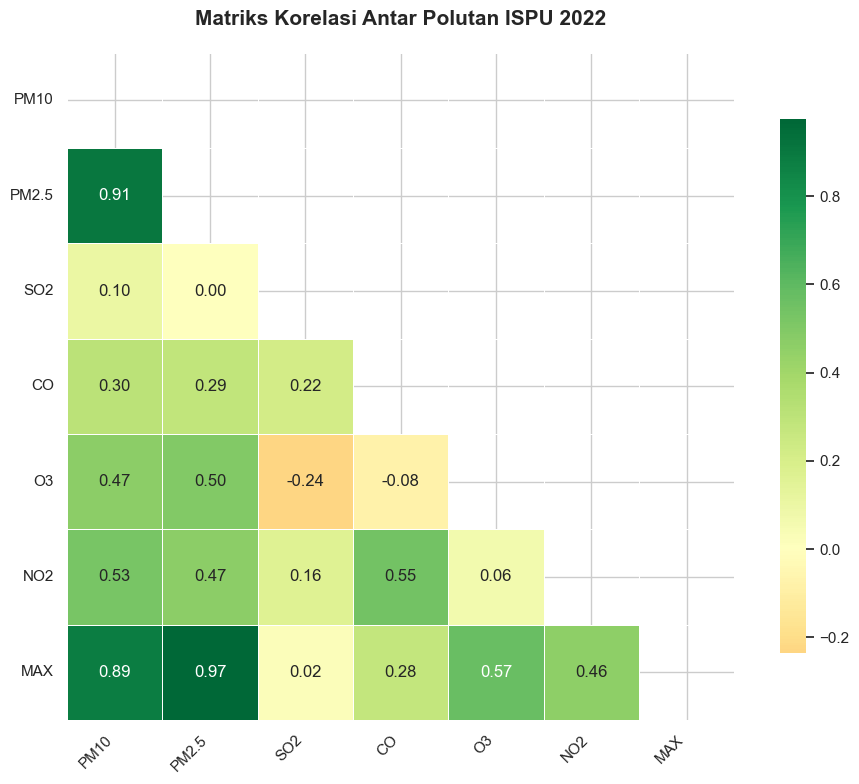

Heatmap korelasi selesai

Korelasi tinggi (>0.7):
  PM10 ↔ PM2.5: 0.909
  PM10 ↔ MAX: 0.889
  PM2.5 ↔ MAX: 0.974


In [9]:
# --- Heatmap Korelasi ---
polutan_cols = ['pm_10', 'pm_duakomalima', 'so2', 'co', 'o3', 'no2', 'max']
corr_matrix  = df[polutan_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=ax,
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)

polutan_labels = ['PM10', 'PM2.5', 'SO2', 'CO', 'O3', 'NO2', 'MAX']
ax.set_xticklabels(polutan_labels, rotation=45, ha='right')
ax.set_yticklabels(polutan_labels, rotation=0)
ax.set_title('Matriks Korelasi Antar Polutan ISPU 2022', fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()
print('Heatmap korelasi selesai')
print()
print('Korelasi tinggi (>0.7):')
for i in range(len(polutan_cols)):
    for j in range(i+1, len(polutan_cols)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            print(f'  {polutan_labels[i]} ↔ {polutan_labels[j]}: {corr_val:.3f}')

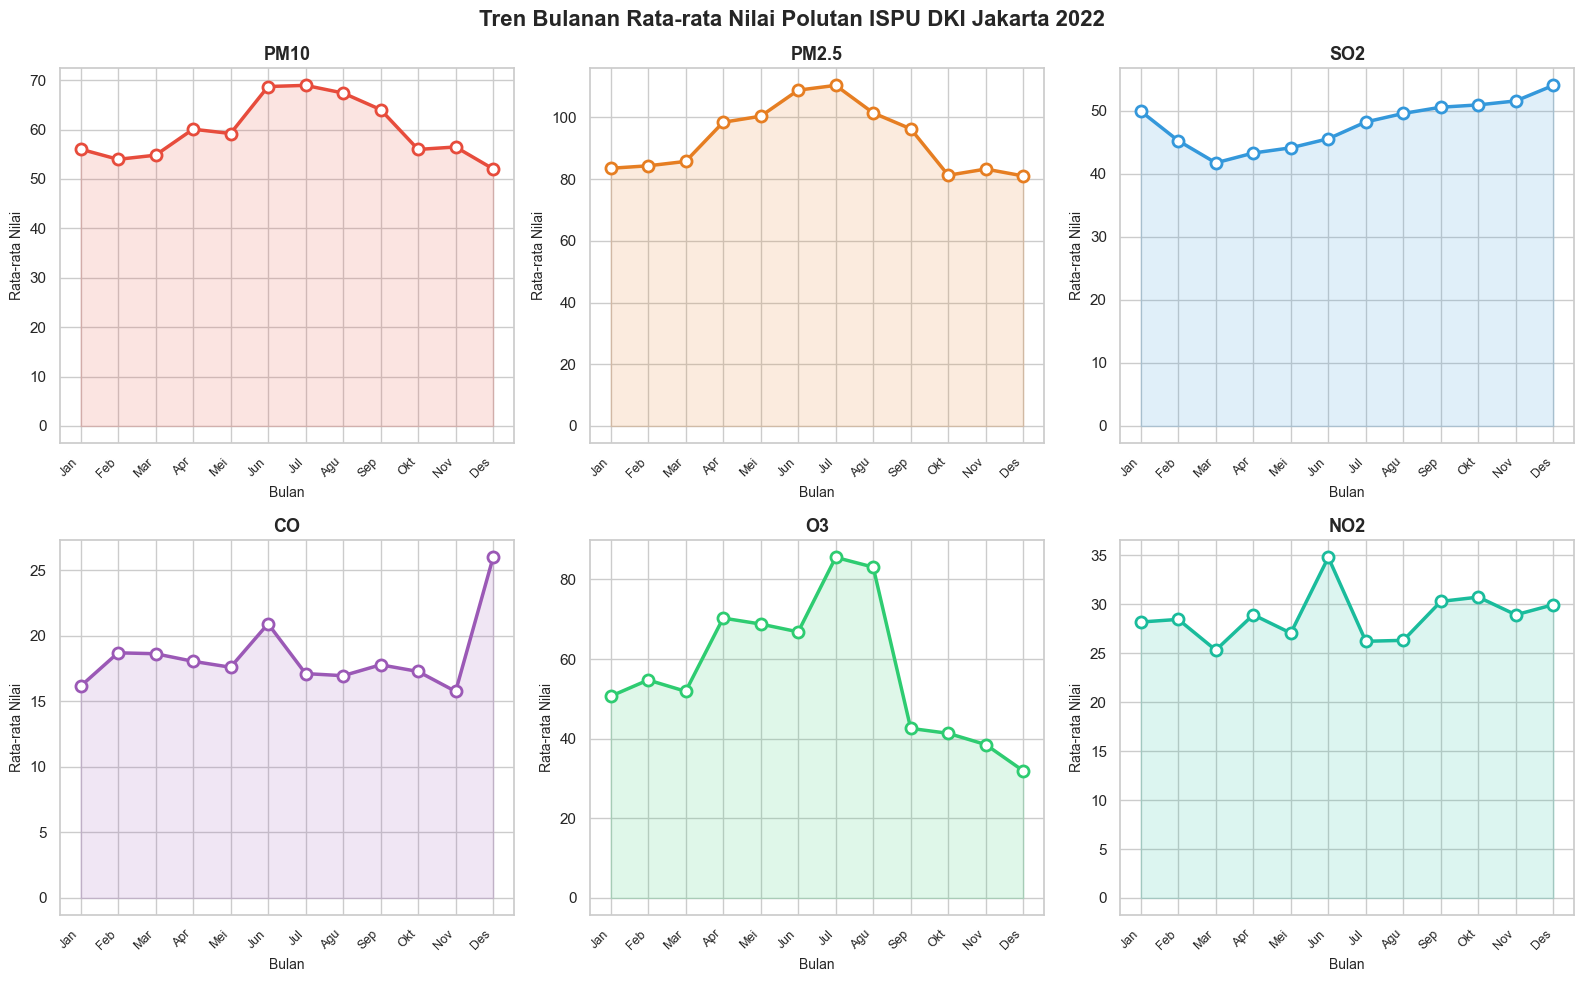

Tren bulanan divisualisasikan

Ringkasan rata-rata per bulan:
           pm_10  pm_duakomalima   so2    co    o3   no2
bulan_num                                               
1          56.00           83.50 49.90 16.20 50.70 28.20
2          54.00           84.30 45.20 18.70 54.80 28.50
3          54.80           85.70 41.70 18.60 51.90 25.30
4          60.10           98.40 43.30 18.10 70.30 28.90
5          59.20          100.40 44.10 17.60 68.80 27.10
6          68.70          108.80 45.60 20.90 66.80 34.80
7          68.90          110.40 48.20 17.10 85.50 26.20
8          67.40          101.50 49.60 17.00 83.10 26.30
9          64.00           96.30 50.60 17.80 42.60 30.30
10         56.00           81.30 50.90 17.30 41.40 30.70
11         56.50           83.30 51.60 15.80 38.50 28.90
12         52.00           81.00 54.00 26.00 31.90 30.00


In [10]:
# --- Tren Temporal Bulanan ---
# Siapkan data sementara untuk visualisasi tren
df_trend = df.copy()
df_trend['bulan_num'] = df_trend['periode_data'].astype(str).str[-2:].astype(int)
monthly_avg = df_trend.groupby('bulan_num')[['pm_10', 'pm_duakomalima', 'so2', 'co', 'o3', 'no2']].mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Tren Bulanan Rata-rata Nilai Polutan ISPU DKI Jakarta 2022',
             fontsize=16, fontweight='bold')

bulan_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
                 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']

for idx, (pol, label, color) in enumerate(zip(
    ['pm_10', 'pm_duakomalima', 'so2', 'co', 'o3', 'no2'],
    ['PM10', 'PM2.5', 'SO2', 'CO', 'O3', 'NO2'],
    ['#e74c3c', '#e67e22', '#3498db', '#9b59b6', '#2ecc71', '#1abc9c']
)):
    ax = axes[idx // 3][idx % 3]
    x  = monthly_avg.index
    y  = monthly_avg[pol]
    ax.plot(x, y, color=color, linewidth=2.5, marker='o', markersize=8,
            markerfacecolor='white', markeredgewidth=2)
    ax.fill_between(x, y, alpha=0.15, color=color)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Bulan', fontsize=10)
    ax.set_ylabel('Rata-rata Nilai', fontsize=10)
    xtick_locs = range(1, len(monthly_avg.index) + 1)
    ax.set_xticks(monthly_avg.index)
    ax.set_xticklabels([bulan_labels[i-1] for i in monthly_avg.index],
                        rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()
print('Tren bulanan divisualisasikan')
print()
print('Ringkasan rata-rata per bulan:')
print(monthly_avg.round(1))

---
## Tahap 3: Data Preprocessing

Berdasarkan Data Understanding, ditemukan beberapa masalah yang perlu ditangani:

| Masalah | Tindakan |
|---|---|
| Duplikasi data | Periksa dan hapus data duplikat jika ditemukan |
| Tanggal Februari tertulis tahun 2020 | Perbaiki menjadi 2022 |
| Tanggal baris terakhir berformat Excel serial number | Konversi ke format date |
| Missing values pada kolom `critical` | Imputasi dengan nilai modus |
| Nilai `0` pada `lokasi_spku` | Perlakukan sebagai NaN, imputasi modus |
| Ketidakseimbangan kelas (BAIK hanya 2 baris) | SMOTE augmentasi |
| Fitur kategorikal (`categori`) | Label Encoding |
| Skala fitur berbeda | StandardScaler |

### Langkah-langkah Preprocessing:
1. **Pengecekan Duplikasi Data** — Periksa data duplikat dan hapus jika ditemukan
2. **Fix Anomali Tanggal** — Perbaiki kesalahan penulisan tahun dan format Excel
3. **Handle Missing Values** — Imputasi dengan modus/median
4. **Feature Engineering** — Ekstrak fitur bulan dan musim dari tanggal
5. **Label Encoding** — Encode variabel target ke integer
6. **SMOTE Augmentasi** — Buat sampel sintetis untuk kelas minoritas (BAIK)
7. **Train-Test Split** — 80:20 dengan stratified sampling
8. **Standarisasi** — StandardScaler untuk normalisasi fitur

In [11]:
# ============================================================
# 3.1 Pengecekan Duplikasi Data & Perbaikan Anomali Tanggal
# ============================================================

df_clean = df.copy()

# --- Pengecekan Duplikasi Data ---
print('=== PENGECEKAN DUPLIKASI DATA ===')
n_duplicates = df_clean.duplicated().sum()
print(f'Jumlah data duplikat: {n_duplicates}')
if n_duplicates > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print(f'Data duplikat berhasil dihapus! Sisa data: {len(df_clean)} baris')
else:
    print('Tidak ditemukan data duplikat dalam dataset.')
print()

print('=== SEBELUM PERBAIKAN TANGGAL ===')
print('Sample tanggal Februari (periode 202202):')
print(df_clean[df_clean['periode_data'] == 202202][['tanggal', 'periode_data']].head(3).to_string())
print()

# --- Fix 1: Tahun 2020 pada data Februari → ganti ke 2022 ---
mask_feb = df_clean['periode_data'] == 202202
df_clean.loc[mask_feb, 'tanggal'] = (
    df_clean.loc[mask_feb, 'tanggal']
    .astype(str)
    .str.replace('2020-02', '2022-02', regex=False)
)
print(f'Fix 1: {mask_feb.sum()} baris Februari diperbaiki dari 2020 → 2022')

# --- Fix 2: Excel serial date → format date ---
def fix_excel_serial(val):
    try:
        val_float = float(str(val))
        if val_float > 40000:  # Angka besar = kemungkinan Excel serial
            from datetime import datetime, timedelta
            excel_epoch = datetime(1899, 12, 30)
            return (excel_epoch + timedelta(days=val_float)).strftime('%Y-%m-%d')
        return str(val)
    except (ValueError, TypeError):
        return str(val)

df_clean['tanggal'] = df_clean['tanggal'].astype(str).apply(fix_excel_serial)

# --- Konversi ke datetime ---
df_clean['tanggal'] = pd.to_datetime(df_clean['tanggal'], errors='coerce')

print()
print('=== SESUDAH PERBAIKAN TANGGAL ===')
print(f'Tanggal tidak valid (NaT): {df_clean["tanggal"].isnull().sum()}')
print(f'Rentang tanggal: {df_clean["tanggal"].min().date()} s/d {df_clean["tanggal"].max().date()}')
print()
print('Sample tanggal Februari setelah perbaikan:')
print(df_clean[df_clean['periode_data'] == 202202][['tanggal', 'periode_data']].head(3).to_string())

=== PENGECEKAN DUPLIKASI DATA ===
Jumlah data duplikat: 0
Tidak ditemukan data duplikat dalam dataset.

=== SEBELUM PERBAIKAN TANGGAL ===
Sample tanggal Februari (periode 202202):
       tanggal  periode_data
31  2020-02-01        202202
32  2020-02-28        202202
33  2020-02-27        202202

Fix 1: 28 baris Februari diperbaiki dari 2020 → 2022

=== SESUDAH PERBAIKAN TANGGAL ===
Tanggal tidak valid (NaT): 0
Rentang tanggal: 2022-01-01 s/d 2022-12-31

Sample tanggal Februari setelah perbaikan:
      tanggal  periode_data
31 2022-02-01        202202
32 2022-02-28        202202
33 2022-02-27        202202


In [12]:
# ============================================================
# 3.2 Penanganan Missing Values
# ============================================================

print('=== MISSING VALUES SEBELUM IMPUTASI ===')
print(df_clean.isnull().sum())
print()

# Fix: Nilai '0' pada lokasi_spku bukan lokasi valid → jadikan NaN
df_clean['lokasi_spku'] = df_clean['lokasi_spku'].replace('0', np.nan).replace(0, np.nan)

# Imputasi: Kolom kategorikal → modus
for col in ['critical', 'lokasi_spku']:
    modus = df_clean[col].mode()[0]
    n_missing = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(modus)
    print(f'  {col}: {n_missing} missing → imputasi dengan modus = "{modus}"')

# Imputasi: Kolom numerik → median
num_cols = ['pm_10', 'pm_duakomalima', 'so2', 'co', 'o3', 'no2', 'max']
for col in num_cols:
    n_missing = df_clean[col].isnull().sum()
    if n_missing > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f'  {col}: {n_missing} missing → imputasi dengan median = {median_val:.2f}')

print()
print('=== MISSING VALUES SESUDAH IMPUTASI ===')
print(df_clean.isnull().sum())
print()
print(f'Semua missing values berhasil ditangani!')
print(f'   Total data: {len(df_clean)} baris')

=== MISSING VALUES SEBELUM IMPUTASI ===
critical          1
categori          0
lokasi_spku       0
periode_data      0
tanggal           0
pm_10             0
pm_duakomalima    0
so2               0
co                0
o3                0
no2               0
max               0
dtype: int64

  critical: 1 missing → imputasi dengan modus = "PM2,5"
  lokasi_spku: 1 missing → imputasi dengan modus = "DKI4"

=== MISSING VALUES SESUDAH IMPUTASI ===
critical          0
categori          0
lokasi_spku       0
periode_data      0
tanggal           0
pm_10             0
pm_duakomalima    0
so2               0
co                0
o3                0
no2               0
max               0
dtype: int64

Semua missing values berhasil ditangani!
   Total data: 365 baris


In [13]:
# ============================================================
# 3.3 Feature Engineering
# ============================================================

# Ekstrak fitur waktu dari kolom tanggal
df_clean['bulan']            = df_clean['tanggal'].dt.month
df_clean['hari_dalam_tahun'] = df_clean['tanggal'].dt.dayofyear

# Tambahkan fitur musim berdasarkan karakteristik iklim DKI Jakarta
def get_musim(bulan):
    if bulan in [12, 1, 2]:
        return 'Hujan_Puncak'     # Curah hujan tertinggi
    elif bulan in [3, 4, 5]:
        return 'Transisi_Hujan_Kemarau'
    elif bulan in [6, 7, 8, 9]:
        return 'Kemarau'          # Udara cenderung lebih kotor
    else:
        return 'Transisi_Kemarau_Hujan'

df_clean['musim'] = df_clean['bulan'].apply(get_musim)

print('=== FEATURE ENGINEERING SELESAI ===')
print(f'Fitur baru: bulan, hari_dalam_tahun, musim')
print()
print('Distribusi berdasarkan musim:')
print(df_clean['musim'].value_counts())
print()
print('Rata-rata PM2.5 per musim:')
print(df_clean.groupby('musim')['pm_duakomalima'].mean().round(2))

=== FEATURE ENGINEERING SELESAI ===
Fitur baru: bulan, hari_dalam_tahun, musim

Distribusi berdasarkan musim:
musim
Kemarau                   122
Transisi_Hujan_Kemarau     92
Hujan_Puncak               90
Transisi_Kemarau_Hujan     61
Name: count, dtype: int64

Rata-rata PM2.5 per musim:
musim
Hujan_Puncak              82.91
Kemarau                  104.27
Transisi_Hujan_Kemarau    94.82
Transisi_Kemarau_Hujan    82.25
Name: pm_duakomalima, dtype: float64


In [14]:
# ============================================================
# 3.4 Label Encoding Target Variable
# ============================================================

le = LabelEncoder()
df_clean['categori_encoded'] = le.fit_transform(df_clean['categori'])

print('=== LABEL ENCODING ===')
print('Mapping kategori → angka:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

print()
print('Distribusi kategori (encoded):')
encoded_counts = df_clean['categori_encoded'].value_counts().sort_index()
for code, count in encoded_counts.items():
    cat_name = le.classes_[code]
    print(f'  {code} ({cat_name:<15}): {count} sampel ({count/len(df_clean)*100:.1f}%)')

print()
print('Terlihat ketidakseimbangan kelas yang signifikan!')
print(f'    BAIK hanya {(df_clean["categori"] == "BAIK").sum()} dari {len(df_clean)} data')
print(f'    Akan diselesaikan dengan SMOTE pada langkah berikutnya')

=== LABEL ENCODING ===
Mapping kategori → angka:
  0 → BAIK
  1 → SEDANG
  2 → TIDAK SEHAT

Distribusi kategori (encoded):
  0 (BAIK           ): 3 sampel (0.8%)
  1 (SEDANG         ): 225 sampel (61.6%)
  2 (TIDAK SEHAT    ): 137 sampel (37.5%)

Terlihat ketidakseimbangan kelas yang signifikan!
    BAIK hanya 3 dari 365 data
    Akan diselesaikan dengan SMOTE pada langkah berikutnya


=== SEBELUM SMOTE ===
Shape X  : (365, 6)
  Kelas 0 (BAIK): 3 sampel
  Kelas 1 (SEDANG): 225 sampel
  Kelas 2 (TIDAK SEHAT): 137 sampel

=== SESUDAH SMOTE ===
Shape X  : (675, 6)
  Kelas 0 (BAIK): 225 sampel
  Kelas 1 (SEDANG): 225 sampel
  Kelas 2 (TIDAK SEHAT): 225 sampel

Augmentasi berhasil!
   Data asli : 365 sampel
   Data baru : 675 sampel (+310 sintetis)


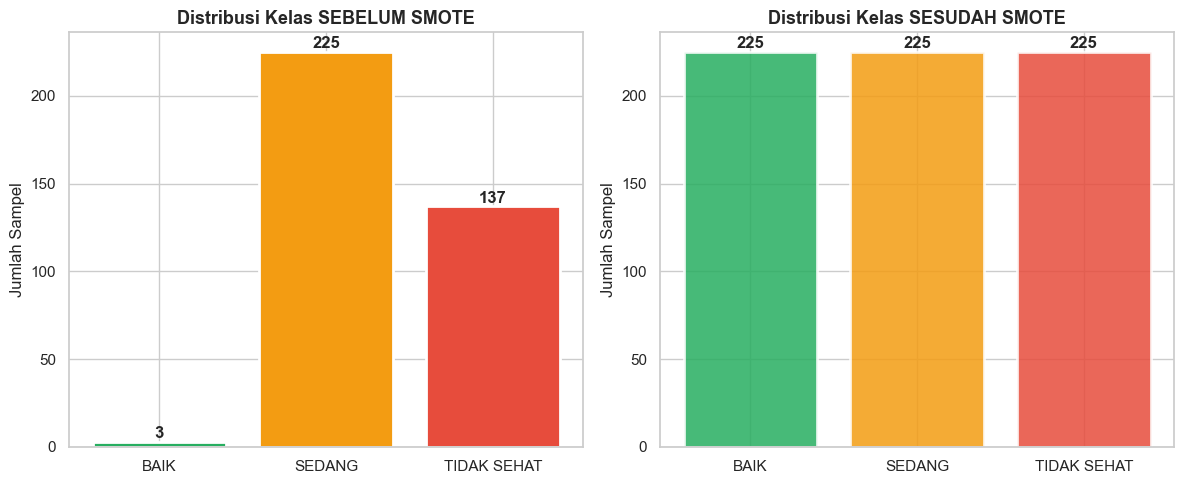

In [15]:
# ============================================================
# 3.5 SMOTE: Augmentasi Data
# ============================================================

# Fitur input (X) dan target (y)
FEATURES = ['pm_10', 'pm_duakomalima', 'so2', 'co', 'o3', 'no2']
TARGET   = 'categori_encoded'

X = df_clean[FEATURES].values
y = df_clean[TARGET].values

print(f'=== SEBELUM SMOTE ===')
print(f'Shape X  : {X.shape}')
for i, cat in enumerate(le.classes_):
    print(f'  Kelas {i} ({cat}): {np.sum(y == i)} sampel')

# SMOTE dengan k_neighbors=1 karena kelas BAIK hanya 2 sampel
# k_neighbors minimal = (jumlah sampel kelas minoritas - 1)
smote = SMOTE(random_state=42, k_neighbors=1)
X_resampled, y_resampled = smote.fit_resample(X, y)

print()
print(f'=== SESUDAH SMOTE ===')
print(f'Shape X  : {X_resampled.shape}')
for i, cat in enumerate(le.classes_):
    count = np.sum(y_resampled == i)
    print(f'  Kelas {i} ({cat}): {count} sampel')

print()
print(f'Augmentasi berhasil!')
print(f'   Data asli : {len(y)} sampel')
print(f'   Data baru : {len(y_resampled)} sampel (+{len(y_resampled) - len(y)} sintetis)')

# Visualisasi sebelum vs sesudah SMOTE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cat_colors = ['#27ae60', '#f39c12', '#e74c3c']

# Sebelum
counts_before = [np.sum(y == i) for i in range(len(le.classes_))]
ax1.bar(le.classes_, counts_before, color=cat_colors, edgecolor='white', linewidth=2)
ax1.set_title('Distribusi Kelas SEBELUM SMOTE', fontsize=13, fontweight='bold')
ax1.set_ylabel('Jumlah Sampel')
for bar, val in zip(ax1.patches, counts_before):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Sesudah
counts_after = [np.sum(y_resampled == i) for i in range(len(le.classes_))]
ax2.bar(le.classes_, counts_after, color=cat_colors, edgecolor='white', linewidth=2, alpha=0.85)
ax2.set_title('Distribusi Kelas SESUDAH SMOTE', fontsize=13, fontweight='bold')
ax2.set_ylabel('Jumlah Sampel')
for bar, val in zip(ax2.patches, counts_after):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 3.6 Train-Test Split & Standarisasi
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled   # Pertahankan proporsi kelas
)

# Standarisasi: fit HANYA pada training data, transform keduanya
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # Gunakan parameter dari training

print('=== PEMBAGIAN DATA ===')
print(f'Total data (setelah SMOTE): {X_resampled.shape[0]} sampel')
print(f'Data training : {X_train.shape[0]} sampel ({X_train.shape[0]/X_resampled.shape[0]*100:.0f}%)')
print(f'Data testing  : {X_test.shape[0]}  sampel ({X_test.shape[0]/X_resampled.shape[0]*100:.0f}%)')
print()
print('Distribusi kelas:')
print(f'  Train: {np.bincount(y_train)} {list(le.classes_)}')
print(f'  Test : {np.bincount(y_test)}  {list(le.classes_)}')
print()
print('=== STANDARISASI ===')
print(f'Mean fitur setelah scaling (≈0): {X_train_scaled.mean(axis=0).round(4)}')
print(f'Std fitur setelah scaling (≈1) : {X_train_scaled.std(axis=0).round(4)}')
print()
print('Data siap untuk pemodelan!')

=== PEMBAGIAN DATA ===
Total data (setelah SMOTE): 675 sampel
Data training : 540 sampel (80%)
Data testing  : 135  sampel (20%)

Distribusi kelas:
  Train: [180 180 180] ['BAIK', 'SEDANG', 'TIDAK SEHAT']
  Test : [45 45 45]  ['BAIK', 'SEDANG', 'TIDAK SEHAT']

=== STANDARISASI ===
Mean fitur setelah scaling (≈0): [-0.  0.  0.  0. -0.  0.]
Std fitur setelah scaling (≈1) : [1. 1. 1. 1. 1. 1.]

Data siap untuk pemodelan!


In [17]:
# ============================================================
# 3.7 Simpan Dataset Hasil Preprocessing
# ============================================================

import os

# Pastikan direktori dataset tersedia
os.makedirs('dataset', exist_ok=True)

# --- Simpan df_clean (hasil preprocessing sebelum SMOTE) ---
SAVE_PATH = 'dataset/ISPU_2022_preprocessed.csv'
df_clean.to_csv(SAVE_PATH, index=False)

print('=== DATASET HASIL PREPROCESSING BERHASIL DISIMPAN ===')
print(f'   File     : {SAVE_PATH}')
print(f'   Ukuran   : {os.path.getsize(SAVE_PATH) / 1024:.2f} KB')
print(f'   Baris    : {df_clean.shape[0]}')
print(f'   Kolom    : {df_clean.shape[1]}')
print()
print('=== KOLOM YANG TERSIMPAN ===')
for col in df_clean.columns:
    print(f'   - {col}')
print()
print('=== PREVIEW DATA TERSIMPAN ===')
df_clean.head()

=== DATASET HASIL PREPROCESSING BERHASIL DISIMPAN ===
   File     : dataset/ISPU_2022_preprocessed.csv
   Ukuran   : 30.69 KB
   Baris    : 365
   Kolom    : 16

=== KOLOM YANG TERSIMPAN ===
   - critical
   - categori
   - lokasi_spku
   - periode_data
   - tanggal
   - pm_10
   - pm_duakomalima
   - so2
   - co
   - o3
   - no2
   - max
   - bulan
   - hari_dalam_tahun
   - musim
   - categori_encoded

=== PREVIEW DATA TERSIMPAN ===


,critical,categori,lokasi_spku,periode_data,tanggal,pm_10,pm_duakomalima,so2,co,o3,no2,max,bulan,hari_dalam_tahun,musim,categori_encoded
0,"PM2,5",SEDANG,DKI4,202201,2022-01-01,57,85,48,13,34,18,85,1,1,Hujan_Puncak,1
1,"PM2,5",TIDAK SEHAT,DKI4,202201,2022-01-31,72,119,58,44,53,44,119,1,31,Hujan_Puncak,2
2,"PM2,5",TIDAK SEHAT,DKI4,202201,2022-01-30,75,129,53,25,59,50,129,1,30,Hujan_Puncak,2
3,"PM2,5",TIDAK SEHAT,DKI4,202201,2022-01-29,65,120,52,30,52,46,120,1,29,Hujan_Puncak,2
4,"PM2,5",SEDANG,DKI3,202201,2022-01-28,63,84,52,12,60,28,84,1,28,Hujan_Puncak,1


---
## Tahap 4: Modelling

Tiga model akan dilatih dan dibandingkan:

| Model | Keunggulan | Kelemahan |
|---|---|---|
| **Decision Tree** | Mudah diinterpretasi, visualisasi pohon | Rentan overfitting |
| **Random Forest** | Robust, akurasi tinggi, feature importance | Kurang interpretable, lambat |
| **KNN** | Sederhana, non-parametrik | Sensitif terhadap skala, lambat pada data besar |

### Strategi Pemilihan Model
Ketiga model dilatih pada data yang sama → dievaluasi → **model dengan F1-Score macro tertinggi dipilih** sebagai model terbaik untuk deployment.

**Mengapa F1-Score macro?**
F1-macro menghitung F1 rata-rata untuk setiap kelas secara independen, sehingga lebih fair untuk dataset yang tidak seimbang (setelah SMOTE, kelas tetap tidak identik).

  MODEL 1: DECISION TREE CLASSIFIER
Accuracy        : 1.0000 (100.00%)
F1-Score (macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

        BAIK       1.00      1.00      1.00        45
      SEDANG       1.00      1.00      1.00        45
 TIDAK SEHAT       1.00      1.00      1.00        45

    accuracy                           1.00       135
   macro avg       1.00      1.00      1.00       135
weighted avg       1.00      1.00      1.00       135



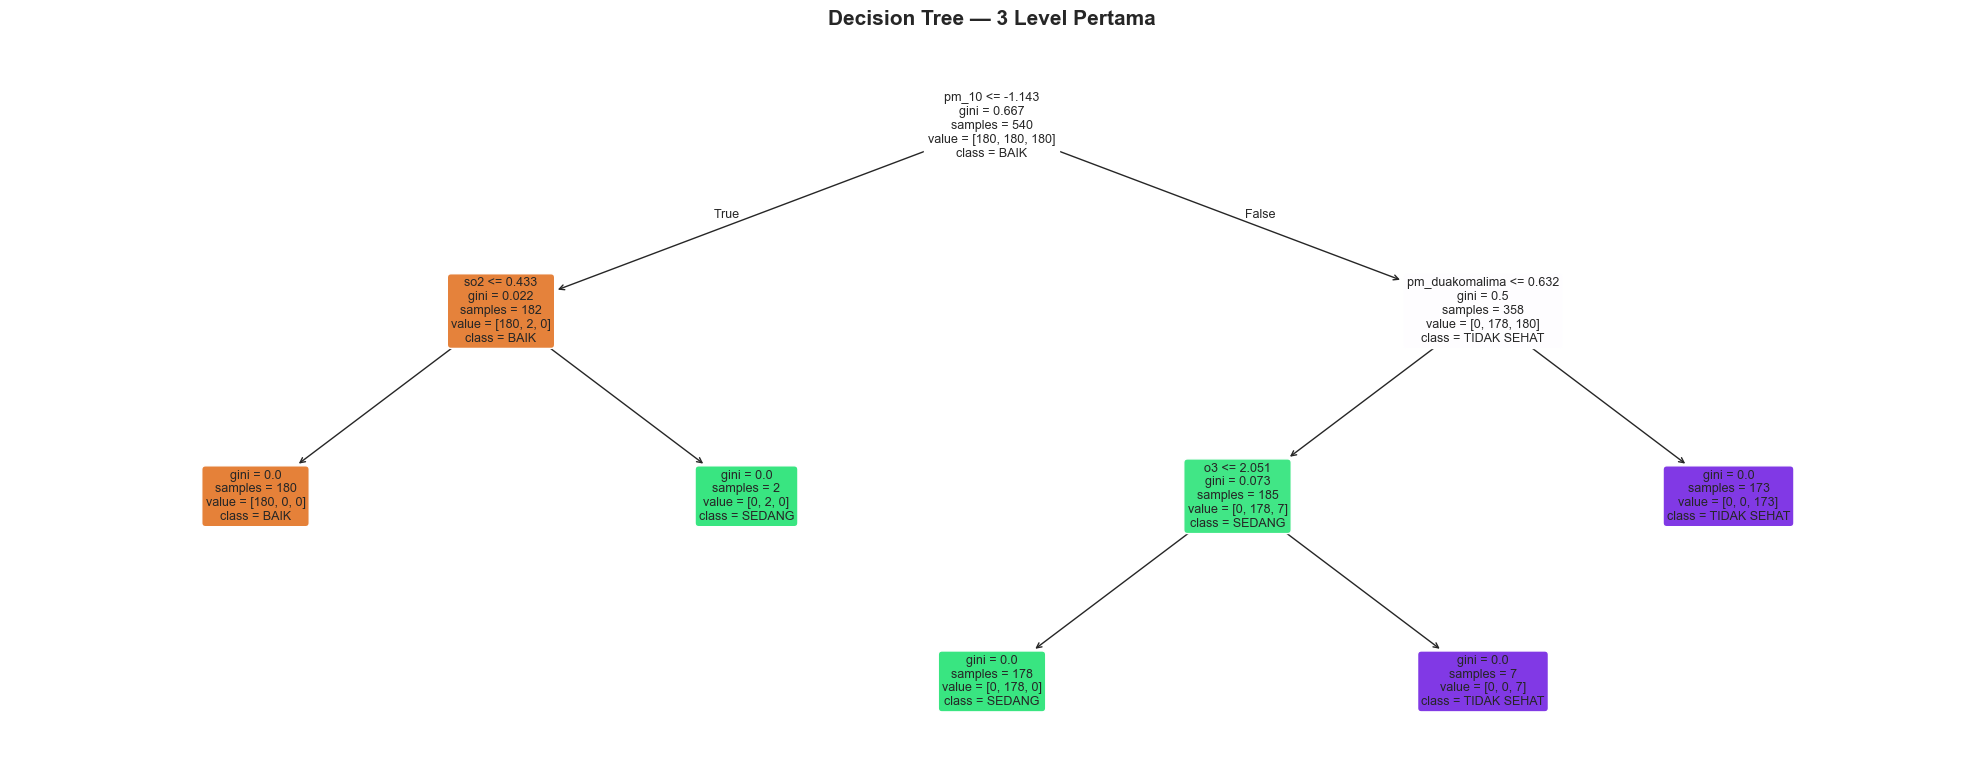

In [18]:
# ============================================================
# MODEL 1: Decision Tree Classifier
# ============================================================
print('=' * 55)
print('  MODEL 1: DECISION TREE CLASSIFIER')
print('=' * 55)

dt_model = DecisionTreeClassifier(
    max_depth=10,           # Batasi kedalaman untuk mencegah overfitting
    min_samples_split=5,   # Min sampel untuk membagi node
    min_samples_leaf=2,    # Min sampel di leaf node
    random_state=42,
    class_weight='balanced' # Beri bobot lebih pada kelas minoritas
)

dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt, average='macro')

print(f'Accuracy        : {acc_dt:.4f} ({acc_dt*100:.2f}%)')
print(f'F1-Score (macro): {f1_dt:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

# Visualisasi Decision Tree (3 level pertama)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_model, max_depth=3, feature_names=FEATURES,
          class_names=list(le.classes_), filled=True,
          rounded=True, fontsize=9, ax=ax)
ax.set_title('Decision Tree — 3 Level Pertama', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# MODEL 2: Random Forest Classifier (Model Utama)
# ============================================================
print('=' * 55)
print('  MODEL 2: RANDOM FOREST CLASSIFIER')
print('=' * 55)

rf_model = RandomForestClassifier(
    n_estimators=200,      # Jumlah pohon dalam forest
    max_depth=15,          # Kedalaman maksimum tiap pohon
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',   # Jumlah fitur yang dipertimbangkan tiap split
    random_state=42,
    class_weight='balanced',
    n_jobs=-1              # Gunakan semua CPU core
)

rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='macro')

print(f'Accuracy        : {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print(f'F1-Score (macro): {f1_rf:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))
print()
print(f'Random Forest menggunakan {rf_model.n_estimators} pohon keputusan')
print(f'Setiap pohon melatih pada subset acak dari data (bagging)')

  MODEL 2: RANDOM FOREST CLASSIFIER
Accuracy        : 1.0000 (100.00%)
F1-Score (macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

        BAIK       1.00      1.00      1.00        45
      SEDANG       1.00      1.00      1.00        45
 TIDAK SEHAT       1.00      1.00      1.00        45

    accuracy                           1.00       135
   macro avg       1.00      1.00      1.00       135
weighted avg       1.00      1.00      1.00       135


Random Forest menggunakan 200 pohon keputusan
Setiap pohon melatih pada subset acak dari data (bagging)


  MODEL 3: K-NEAREST NEIGHBORS (KNN)
Mencari K optimal dengan 5-fold cross-validation...
K terbaik: 1 | F1-macro CV: 0.9402


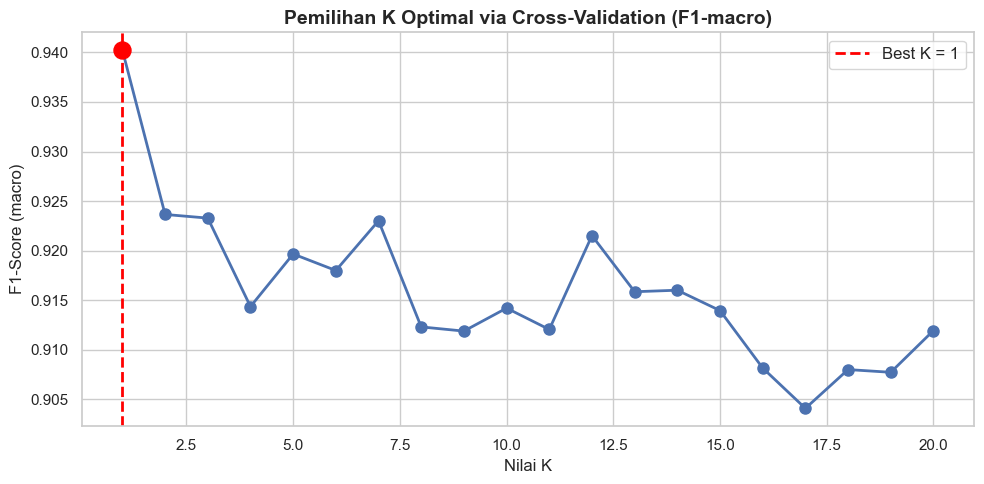


Accuracy        : 0.9778 (97.78%)
F1-Score (macro): 0.9778

Classification Report:
              precision    recall  f1-score   support

        BAIK       1.00      1.00      1.00        45
      SEDANG       0.96      0.98      0.97        45
 TIDAK SEHAT       0.98      0.96      0.97        45

    accuracy                           0.98       135
   macro avg       0.98      0.98      0.98       135
weighted avg       0.98      0.98      0.98       135



In [20]:
# ============================================================
# MODEL 3: K-Nearest Neighbors
# ============================================================
print('=' * 55)
print('  MODEL 3: K-NEAREST NEIGHBORS (KNN)')
print('=' * 55)

# Cari nilai K terbaik menggunakan Stratified K-Fold Cross-Validation
k_values  = range(1, 21)
cv_scores = []
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Mencari K optimal dengan 5-fold cross-validation...')
for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    score    = cross_val_score(knn_temp, X_train_scaled, y_train, cv=kf, scoring='f1_macro')
    cv_scores.append(score.mean())

best_k = list(k_values)[np.argmax(cv_scores)]
print(f'K terbaik: {best_k} | F1-macro CV: {max(cv_scores):.4f}')

# Plot K vs F1-Score
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_values), cv_scores, 'bo-', linewidth=2, markersize=8)
ax.axvline(best_k, color='red', linestyle='--', linewidth=2, label=f'Best K = {best_k}')
ax.scatter([best_k], [max(cv_scores)], color='red', s=150, zorder=5)
ax.set_title('Pemilihan K Optimal via Cross-Validation (F1-macro)', fontsize=14, fontweight='bold')
ax.set_xlabel('Nilai K', fontsize=12)
ax.set_ylabel('F1-Score (macro)', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True)
plt.tight_layout()
plt.show()

# Train KNN dengan K terbaik
knn_model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn, average='macro')

print()
print(f'Accuracy        : {acc_knn:.4f} ({acc_knn*100:.2f}%)')
print(f'F1-Score (macro): {f1_knn:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

=== TABEL PERBANDINGAN MODEL ===
               Accuracy  F1 (macro)  Precision  Recall
Model                                                 
Decision Tree      1.00        1.00       1.00    1.00
Random Forest      1.00        1.00       1.00    1.00
KNN                0.98        0.98       0.98    0.98


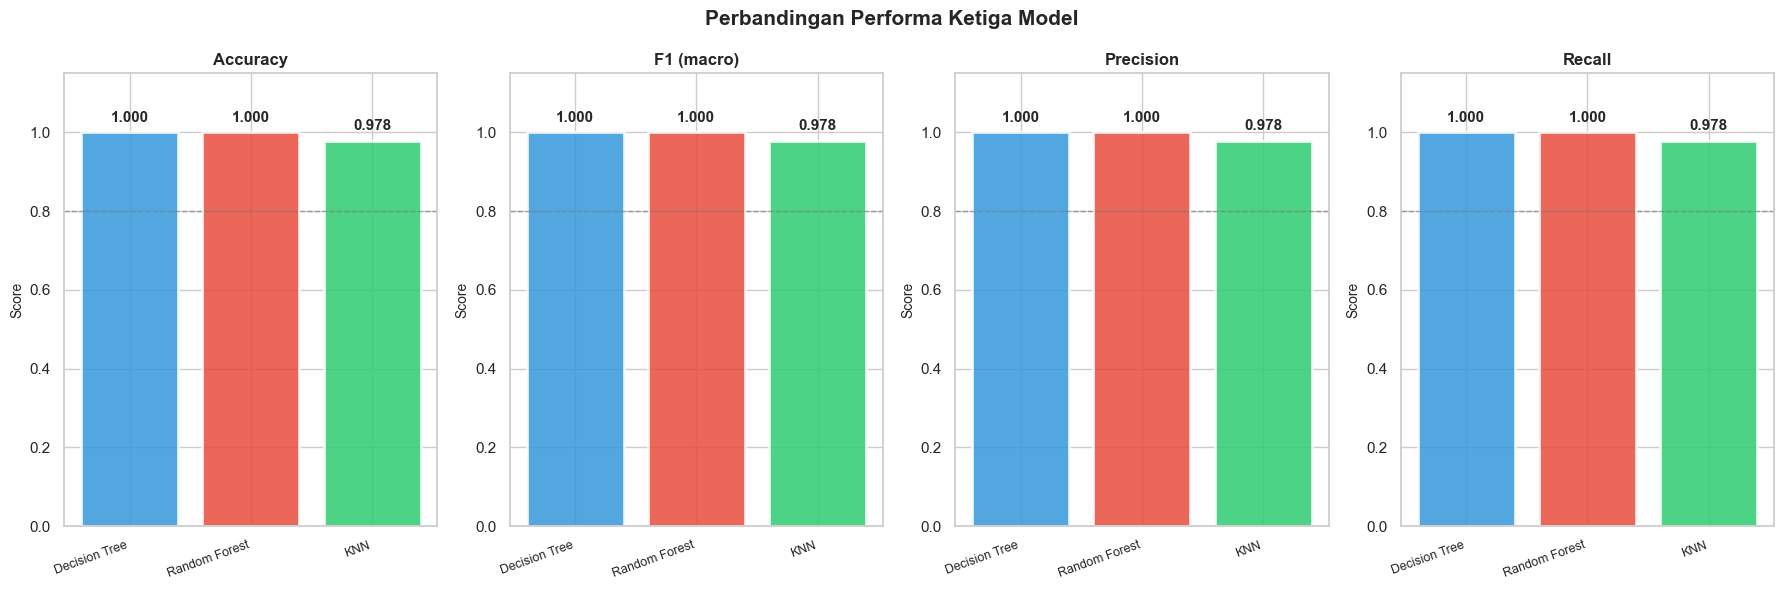


MODEL TERBAIK: Decision Tree
   Berdasarkan: F1-Score macro tertinggi
   Accuracy   : 1.0000
   F1 (macro) : 1.0000


In [21]:
# ============================================================
# PERBANDINGAN KETIGA MODEL
# ============================================================

results = {
    'Decision Tree': {
        'model'    : dt_model,
        'y_pred'   : y_pred_dt,
        'accuracy' : acc_dt,
        'f1_macro' : f1_dt,
        'precision': precision_score(y_test, y_pred_dt, average='macro'),
        'recall'   : recall_score(y_test, y_pred_dt, average='macro')
    },
    'Random Forest': {
        'model'    : rf_model,
        'y_pred'   : y_pred_rf,
        'accuracy' : acc_rf,
        'f1_macro' : f1_rf,
        'precision': precision_score(y_test, y_pred_rf, average='macro'),
        'recall'   : recall_score(y_test, y_pred_rf, average='macro')
    },
    'KNN': {
        'model'    : knn_model,
        'y_pred'   : y_pred_knn,
        'accuracy' : acc_knn,
        'f1_macro' : f1_knn,
        'precision': precision_score(y_test, y_pred_knn, average='macro'),
        'recall'   : recall_score(y_test, y_pred_knn, average='macro')
    }
}

# Tabel perbandingan
comparison_df = pd.DataFrame({
    'Model'     : list(results.keys()),
    'Accuracy'  : [v['accuracy']  for v in results.values()],
    'F1 (macro)': [v['f1_macro']  for v in results.values()],
    'Precision' : [v['precision'] for v in results.values()],
    'Recall'    : [v['recall']    for v in results.values()]
}).set_index('Model')

print('=== TABEL PERBANDINGAN MODEL ===')
print(comparison_df.round(4))

# Bar chart perbandingan
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('Perbandingan Performa Ketiga Model', fontsize=15, fontweight='bold')

metrics_list = ['Accuracy', 'F1 (macro)', 'Precision', 'Recall']
colors_models = ['#3498db', '#e74c3c', '#2ecc71']

for ax, metric in zip(axes, metrics_list):
    vals = comparison_df[metric].values
    bars = ax.bar(comparison_df.index, vals, color=colors_models, alpha=0.85, edgecolor='white', linewidth=2)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score', fontsize=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_xticklabels(comparison_df.index, rotation=20, ha='right', fontsize=9)
    ax.axhline(0.8, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Target 80%')

plt.tight_layout()
plt.show()

# Pilih model terbaik
best_model_name = comparison_df['F1 (macro)'].idxmax()
best_model      = results[best_model_name]['model']
best_y_pred     = results[best_model_name]['y_pred']

print()
print(f'MODEL TERBAIK: {best_model_name}')
print(f'   Berdasarkan: F1-Score macro tertinggi')
print(f'   Accuracy   : {results[best_model_name]["accuracy"]:.4f}')
print(f'   F1 (macro) : {results[best_model_name]["f1_macro"]:.4f}')

---
## Tahap 5: Evaluation

Evaluasi dilakukan secara menyeluruh menggunakan:
- **Confusion Matrix** — visualisasi kesalahan prediksi per kelas
- **Feature Importance** — polutan mana yang paling berpengaruh
- **Boxplot per Kategori** — distribusi polutan berdasarkan kategori
- **Cross-Validation** — validasi dengan 5-fold untuk ketahanan hasil

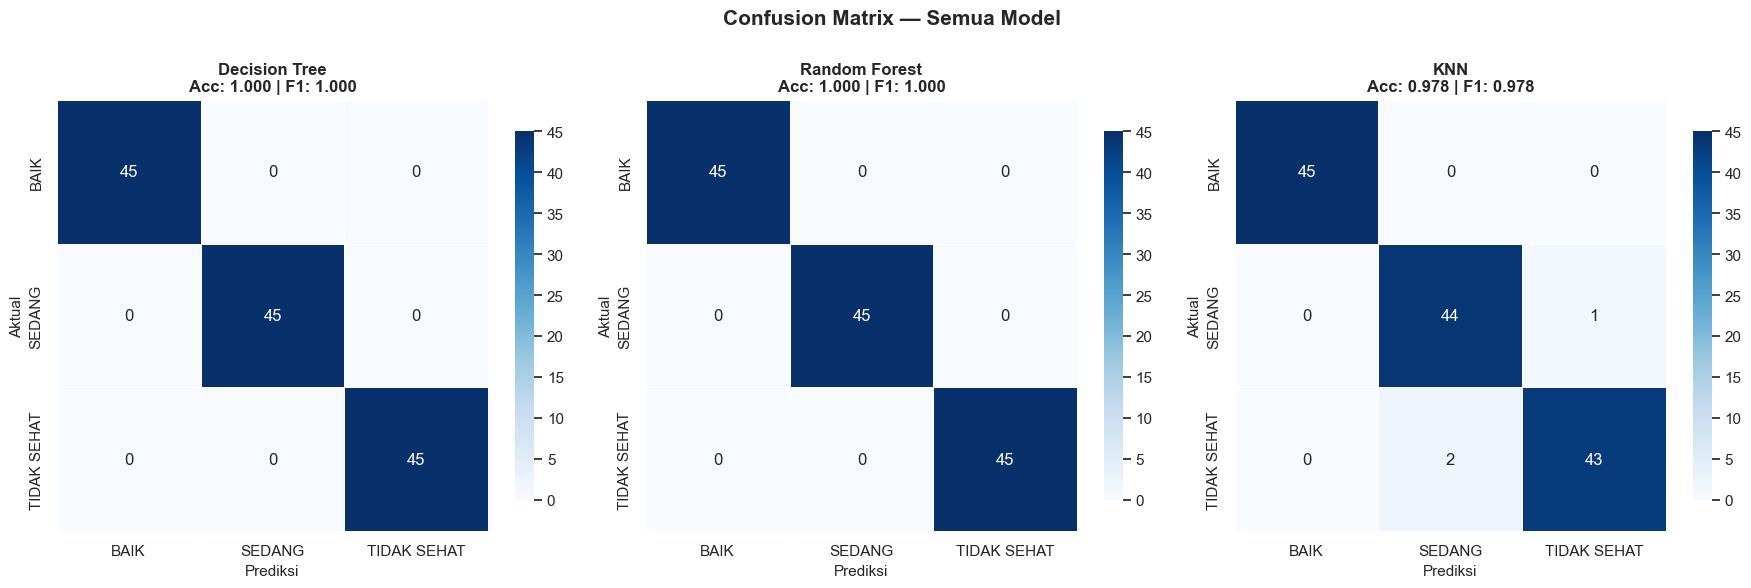

=== Confusion Matrix Detail: Decision Tree ===
Prediksi     BAIK  SEDANG  TIDAK SEHAT
Aktual                                
BAIK           45       0            0
SEDANG          0      45            0
TIDAK SEHAT     0       0           45


In [22]:
# ============================================================
# Confusion Matrix — Semua Model
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Confusion Matrix — Semua Model', fontsize=15, fontweight='bold')

for ax, (model_name, model_data) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, model_data['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=ax, linewidths=0.5, square=True,
        cbar_kws={'shrink': 0.7}
    )
    ax.set_title(
        f'{model_name}\nAcc: {model_data["accuracy"]:.3f} | F1: {model_data["f1_macro"]:.3f}',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('Prediksi', fontsize=11)
    ax.set_ylabel('Aktual', fontsize=11)

plt.tight_layout()
plt.show()

# Detail confusion matrix model terbaik
print(f'=== Confusion Matrix Detail: {best_model_name} ===')
cm_best = confusion_matrix(y_test, best_y_pred)
cm_df = pd.DataFrame(cm_best, index=le.classes_, columns=le.classes_)
cm_df.index.name = 'Aktual'
cm_df.columns.name = 'Prediksi'
print(cm_df)

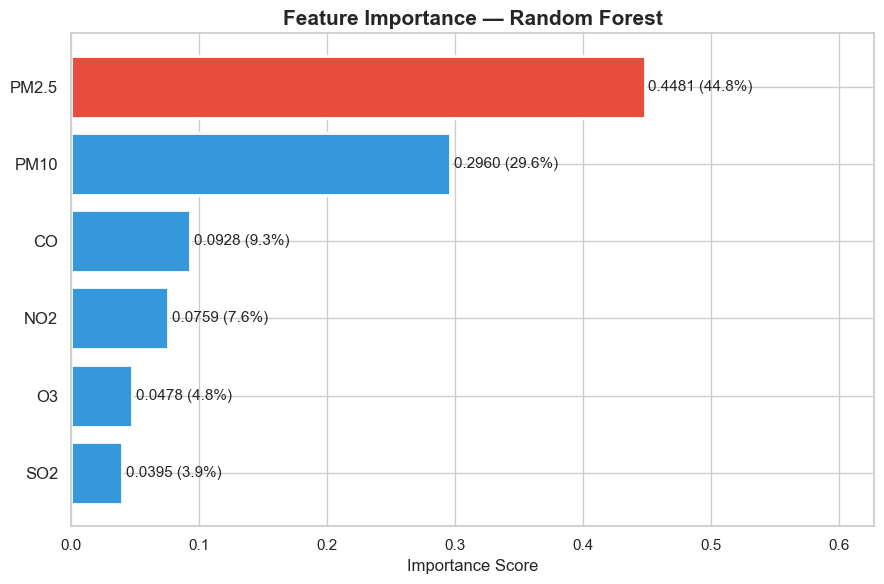

Ranking Polutan berdasarkan Feature Importance (Random Forest):
  1. PM2.5   : 0.4481 (44.8%)
  2. PM10    : 0.2960 (29.6%)
  3. CO      : 0.0928 (9.3%)
  4. NO2     : 0.0759 (7.6%)
  5. O3      : 0.0478 (4.8%)
  6. SO2     : 0.0395 (3.9%)


In [23]:
# ============================================================
# Feature Importance (Random Forest)
# ============================================================

fi_labels = {'pm_10': 'PM10', 'pm_duakomalima': 'PM2.5',
              'so2': 'SO2', 'co': 'CO', 'o3': 'O3', 'no2': 'NO2'}

fi = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_fi = ['#e74c3c' if v == fi.max() else '#3498db' for v in fi.values]
bars = ax.barh([fi_labels.get(f, f) for f in fi.index], fi.values,
                color=colors_fi, edgecolor='white', linewidth=2)

for bar, val in zip(bars, fi.values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f} ({val*100:.1f}%)', va='center', fontsize=11)

ax.set_title('Feature Importance — Random Forest', fontsize=15, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_xlim(0, fi.max() * 1.4)
ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()

print('Ranking Polutan berdasarkan Feature Importance (Random Forest):')
for rank, (feat, imp) in enumerate(fi.sort_values(ascending=False).items(), 1):
    label = fi_labels.get(feat, feat)
    print(f'  {rank}. {label:<8}: {imp:.4f} ({imp*100:.1f}%)')

In [24]:
# ============================================================
# Cross-Validation: Validasi Ketahanan Model
# ============================================================

print('=== CROSS-VALIDATION (5-Fold Stratified) ===')
print()

kf_cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in [('Decision Tree', dt_model),
                     ('Random Forest', rf_model),
                     ('KNN', knn_model)]:
    cv_acc = cross_val_score(model, X_resampled, y_resampled, cv=kf_cv, scoring='accuracy')
    cv_f1  = cross_val_score(model, X_resampled, y_resampled, cv=kf_cv, scoring='f1_macro')
    cv_results[name] = {'acc_mean': cv_acc.mean(), 'acc_std': cv_acc.std(),
                          'f1_mean': cv_f1.mean(), 'f1_std': cv_f1.std()}
    print(f'{name}:')
    print(f'  CV Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
    print(f'  CV F1-macro : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
    print()

# Ringkasan evaluasi final
print('=' * 55)
print('  RINGKASAN EVALUASI FINAL')
print('=' * 55)
print(f'Model Terbaik : {best_model_name}')
print(f'Accuracy Test : {results[best_model_name]["accuracy"]:.4f}')
print(f'F1 macro Test : {results[best_model_name]["f1_macro"]:.4f}')
print(f'Precision     : {results[best_model_name]["precision"]:.4f}')
print(f'Recall        : {results[best_model_name]["recall"]:.4f}')
print()
target_acc = results[best_model_name]['accuracy'] >= 0.80
target_f1  = results[best_model_name]['f1_macro'] >= 0.75
print(f'Kriteria Keberhasilan:')
print(f'  Accuracy ≥ 80%   : {"TERCAPAI" if target_acc else "BELUM"}')
print(f'  F1-macro ≥ 0.75  : {"TERCAPAI" if target_f1 else "BELUM"}')

=== CROSS-VALIDATION (5-Fold Stratified) ===

Decision Tree:
  CV Accuracy : 0.9941 ± 0.0086
  CV F1-macro : 0.9941 ± 0.0086

Random Forest:
  CV Accuracy : 0.9970 ± 0.0036
  CV F1-macro : 0.9970 ± 0.0036

KNN:
  CV Accuracy : 0.9704 ± 0.0141
  CV F1-macro : 0.9701 ± 0.0143

  RINGKASAN EVALUASI FINAL
Model Terbaik : Decision Tree
Accuracy Test : 1.0000
F1 macro Test : 1.0000
Precision     : 1.0000
Recall        : 1.0000

Kriteria Keberhasilan:
  Accuracy ≥ 80%   : TERCAPAI
  F1-macro ≥ 0.75  : TERCAPAI


---
## Tahap 6: Deployment

Model terbaik disimpan ke disk menggunakan **joblib** untuk digunakan pada:
1. **Streamlit Dashboard** (`dashboard/dashboard.py`) — prediksi real-time interaktif
2. **API/Produksi** — integrasi ke sistem monitoring udara

### File yang disimpan:
| File | Fungsi |
|---|---|
| `model/best_model.pkl` | Model ML terlatih (terbaik) |
| `model/scaler.pkl` | StandardScaler untuk normalisasi input baru |
| `model/label_encoder.pkl` | LabelEncoder untuk decode prediksi ke label asli |
| `model/model_info.json` | Metadata model (nama, fitur, metrik) |

### Cara Menjalankan Dashboard:
```bash
# Dari direktori root proyek:
streamlit run dashboard/dashboard.py
```

In [25]:
# ============================================================
# SIMPAN MODEL KE DISK
# ============================================================

# Buat direktori model
os.makedirs('model', exist_ok=True)

# Simpan model terbaik, scaler, dan label encoder
joblib.dump(best_model, 'model/best_model.pkl')
joblib.dump(scaler,     'model/scaler.pkl')
joblib.dump(le,         'model/label_encoder.pkl')

# Simpan metadata model
model_info = {
    'best_model_name': best_model_name,
    'features'       : FEATURES,
    'classes'        : list(le.classes_),
    'accuracy'       : round(results[best_model_name]['accuracy'], 4),
    'f1_macro'       : round(results[best_model_name]['f1_macro'], 4),
    'precision'      : round(results[best_model_name]['precision'], 4),
    'recall'         : round(results[best_model_name]['recall'], 4),
    'train_samples'  : int(X_train.shape[0]),
    'test_samples'   : int(X_test.shape[0]),
    'smote_applied'  : True
}

with open('model/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

# Verifikasi: coba load model dan prediksi
loaded_model   = joblib.load('model/best_model.pkl')
loaded_scaler  = joblib.load('model/scaler.pkl')
loaded_le      = joblib.load('model/label_encoder.pkl')
sample_input   = X_test_scaled[:3]
sample_pred    = loaded_le.inverse_transform(loaded_model.predict(sample_input))
sample_actual  = loaded_le.inverse_transform(y_test[:3])

print(' MODEL BERHASIL DISIMPAN!')

print()
print('=' * 55)
print('  CRISP-DM SELESAI!')
print('=' * 55)
print(f'  Model: {best_model_name}')
print(f'  Akurasi: {results[best_model_name]["accuracy"]*100:.2f}%')
print(f'  F1-Score: {results[best_model_name]["f1_macro"]:.4f}')
print()
print('  Jalankan dashboard:')
print('  streamlit run dashboard/dashboard.py')

 MODEL BERHASIL DISIMPAN!

  CRISP-DM SELESAI!
  Model: Decision Tree
  Akurasi: 100.00%
  F1-Score: 1.0000

  Jalankan dashboard:
  streamlit run dashboard/dashboard.py
